Data loaded successfully. Shape: (100, 14)

--- Model Evaluation ---
Linear Regression  -> R²: 0.7903
Random Forest      -> R²: 0.8545


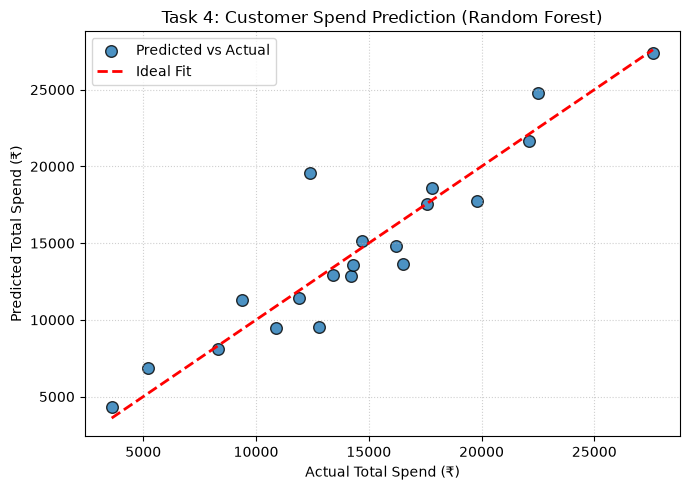

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

df = pd.read_excel('Customer_Data_Analysis_Dataset.xlsx')
print('Data loaded successfully. Shape:', df.shape)

features = ['Age', 'Gender', 'Preferred_Category', 'Purchase_Frequency', 
            'Last_Purchase_Days_Ago', 'Customer_Rating', 'Payment_Method']
X = pd.get_dummies(df[features], drop_first=True)
y = df['Total_Spend']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print('\n--- Model Evaluation ---')
print(f'Linear Regression  -> R²: {r2_score(y_test, lr_pred):.4f}')
print(f'Random Forest      -> R²: {r2_score(y_test, rf_pred):.4f}')

plt.figure(figsize=(7, 5))
plt.scatter(y_test, rf_pred, color='#1f77b4', edgecolors='k', alpha=0.8, s=70, label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal Fit')
plt.title('Task 4: Customer Spend Prediction (Random Forest)', fontsize=12)
plt.xlabel('Actual Total Spend (₹)')
plt.ylabel('Predicted Total Spend (₹)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()

plt.savefig('task4_preview.png', dpi=300)
plt.show()